# **Training Notebook**

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import sklearn
import os
import utils

## Data loading

In [2]:
# Define the path as required by the guide
data_path = os.path.expanduser("~/Datasets/QuoraQuestionPairs/quora_data.csv")

quora_df = pd.read_csv(data_path)

display(quora_df)
display(quora_df.dtypes)

,id,qid1,qid2,question1,question2,is_duplicate
0,346692,38482,10706,Why do I get easily bored with everything?,Why do I get bored with things so quickly and ...,1
1,327668,454117,345117,How do I study for Honeywell company recruitment?,How do I study for Honeywell company recruitme...,1
2,272993,391373,391374,Which search engine algorithm is Quora using?,Why is Quora not using reliable search engine?,0
3,54070,82673,95496,How can I smartly cut myself?,Can someone who thinks about suicide for 7 yea...,0
4,46450,38384,72436,How do I see who is viewing my Instagram videos?,Can one tell who viewed my Instagram videos?,1
...,...,...,...,...,...,...
323427,192476,292119,292120,Is it okay to use a laptop while it is chargin...,Is it OK to use your phone while charging?,0
323428,17730,33641,33642,How can dogs understand human language?,Can dogs understand the human language?,0
323429,28030,52012,52013,What's your favourite lotion?,What's your favourite skin lotion?,1
323430,277869,397054,120852,How does one become a hedge fund manager?,What should I do to become a hedge fund manager?,1


id               int64
qid1             int64
qid2             int64
question1       object
question2       object
is_duplicate     int64
dtype: object

## Data Analysis

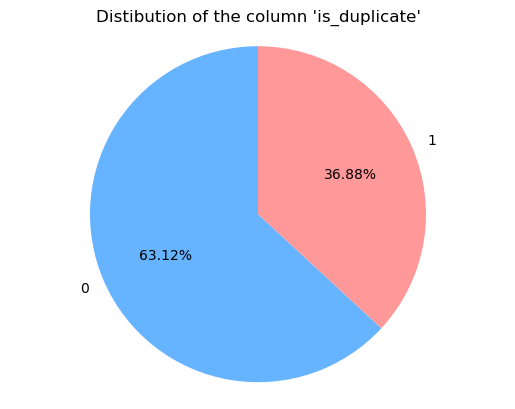

In [3]:
import matplotlib.pyplot as plt

counts = quora_df['is_duplicate'].value_counts()

colors = ['#66b3ff', '#ff9999']

plt.pie(
    counts, 
    labels=counts.index,
    autopct='%1.2f%%',
    startangle=90,
    colors=colors
)

plt.title("Distibution of the column 'is_duplicate'")
plt.axis('equal')
plt.show()

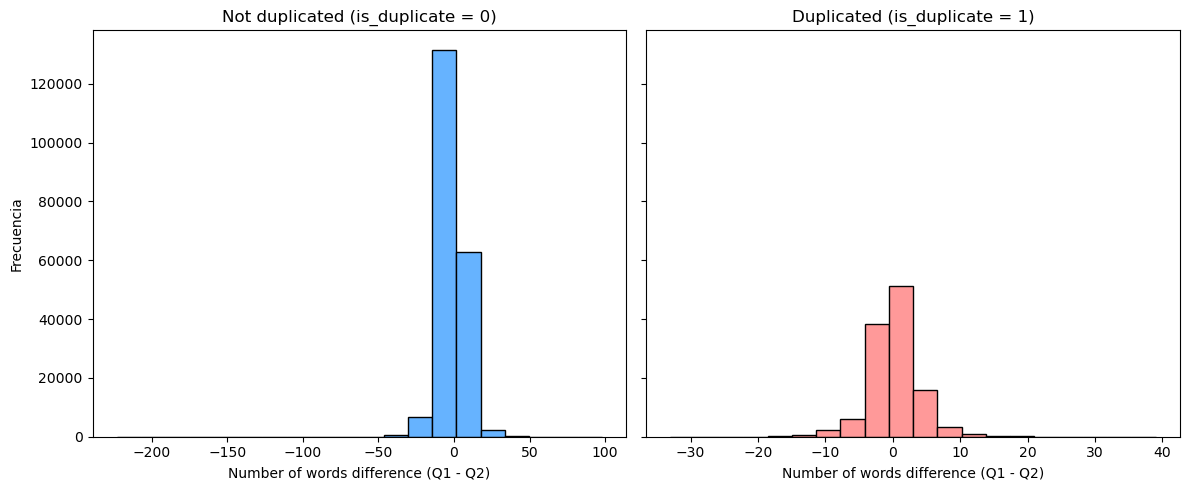

In [4]:
import matplotlib.pyplot as plt

copy_df = quora_df.copy()

copy_df['word_diff'] = copy_df['question1'].apply(lambda x: len(str(x).split())) - \
                       copy_df['question2'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

colors = ['#66b3ff', '#ff9999']

# Graph for is_duplicated = 0
axes[0].hist(copy_df[copy_df['is_duplicate'] == 0]['word_diff'], bins=20, color=colors[0], edgecolor='black')
axes[0].set_title('Not duplicated (is_duplicate = 0)')
axes[0].set_xlabel('Number of words difference (Q1 - Q2)')
axes[0].set_ylabel('Frecuencia')

# Graph for is_duplicated = 1
axes[1].hist(copy_df[copy_df['is_duplicate'] == 1]['word_diff'], bins=20, color=colors[1], edgecolor='black')
axes[1].set_title('Duplicated (is_duplicate = 1)')
axes[1].set_xlabel('Number of words difference (Q1 - Q2)')

plt.tight_layout()
plt.show()

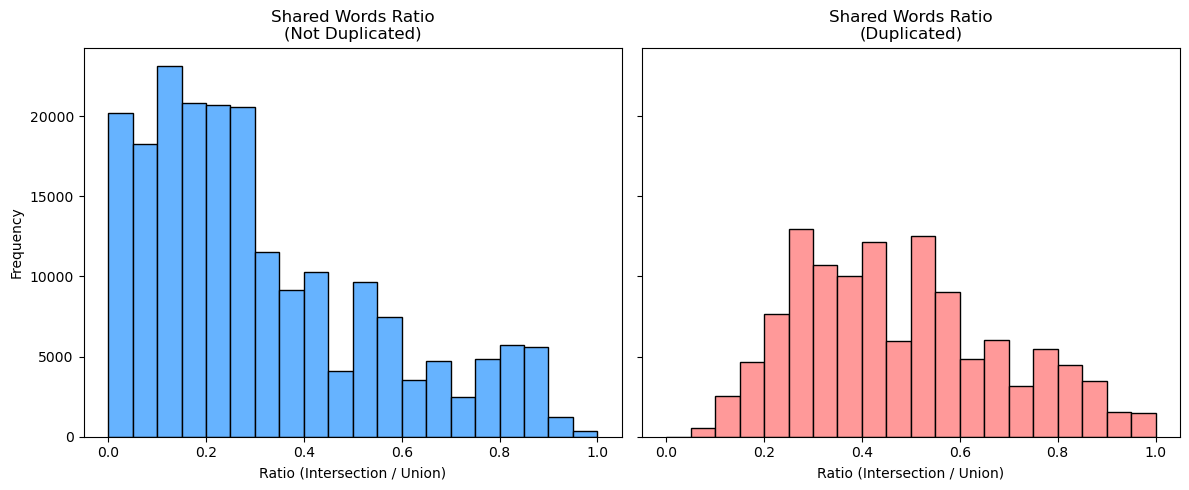

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import re

# Create a copy to avoid modifying the original dataframe
copy_df = quora_df.copy()

# Pre-compile the regex pattern
word_pattern = re.compile(r'\w+')

# Jaccard Similarity = (Intersection of Words) / (Union of Words)
ratios = []
for q1, q2 in zip(copy_df['question1'], copy_df['question2']):
    set_q1 = set(word_pattern.findall(str(q1).lower()))
    set_q2 = set(word_pattern.findall(str(q2).lower()))
    
    # Calculate intersection and union
    intersection = len(set_q1 & set_q2)
    union = len(set_q1 | set_q2)
    
    # Avoid division by zero if both strings are empty or have no words
    if union == 0:
        ratio = 0
    else:
        ratio = intersection / union
        
    ratios.append(ratio)

copy_df['shared_words_ratio'] = ratios


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

colors = ['#66b3ff', '#ff9999']

# Histogram for is_duplicate = 0
# Ratios are always between 0.0 and 1.0, so bins=20 nicely divides it into 5% chunks
axes[0].hist(copy_df[copy_df['is_duplicate'] == 0]['shared_words_ratio'], 
             bins=20, range=(0, 1), color=colors[0], edgecolor='black')
axes[0].set_title('Shared Words Ratio\n(Not Duplicated)')
axes[0].set_xlabel('Ratio (Intersection / Union)')
axes[0].set_ylabel('Frequency')

# Histogram for is_duplicate = 1
axes[1].hist(copy_df[copy_df['is_duplicate'] == 1]['shared_words_ratio'], 
             bins=20, range=(0, 1), color=colors[1], edgecolor='black')
axes[1].set_title('Shared Words Ratio\n(Duplicated)')
axes[1].set_xlabel('Ratio (Intersection / Union)')

# Adjust layout
plt.tight_layout()
plt.show()

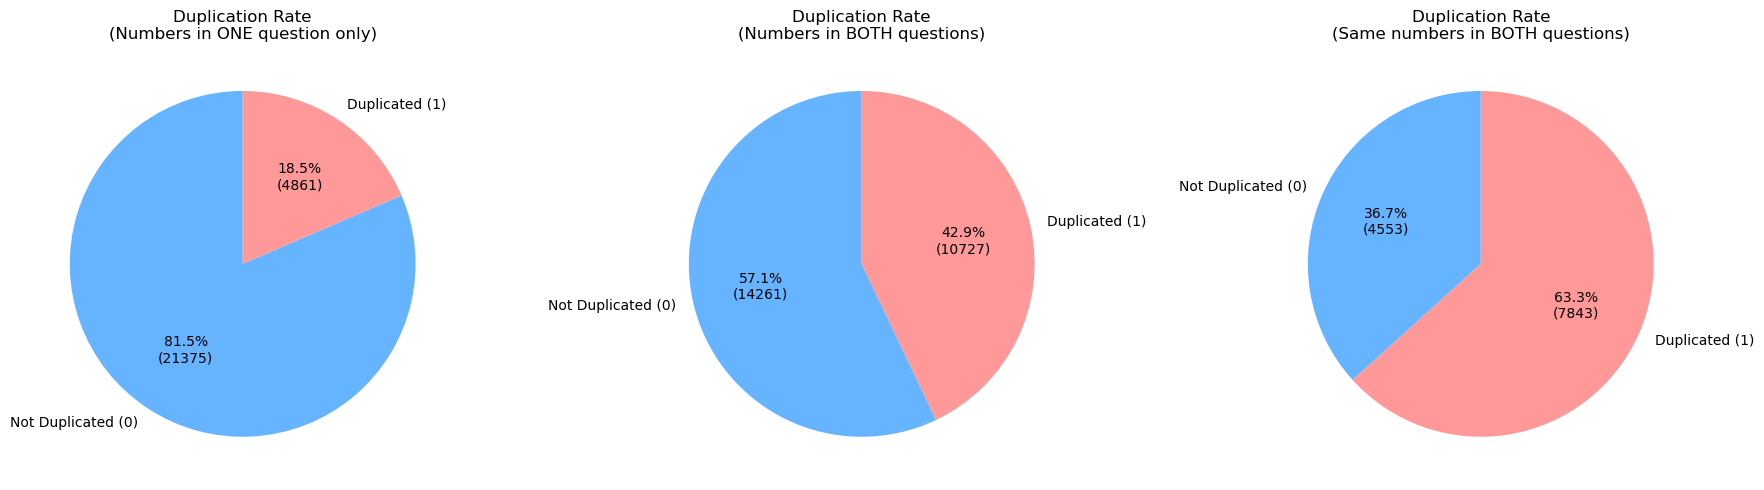

In [6]:
import matplotlib.pyplot as plt
import re

copy_df = quora_df.copy()

# Pre-compile the regex pattern and extract sets of numbers
number_pattern = re.compile(r'\d+')
copy_df['nums_q1'] = [set(number_pattern.findall(str(text))) for text in copy_df['question1']]
copy_df['nums_q2'] = [set(number_pattern.findall(str(text))) for text in copy_df['question2']]

# Calculate lengths using vectorized string operations
len_q1 = copy_df['nums_q1'].str.len()
len_q2 = copy_df['nums_q2'].str.len()

# Create boolean masks for our 3 specific conditions
# - Condition 1: Numbers in only one of the questions (XOR logic)
mask_only_one = ((len_q1 > 0) & (len_q2 == 0)) | ((len_q1 == 0) & (len_q2 > 0))

# - Condition 2: Numbers in both questions
mask_both = (len_q1 > 0) & (len_q2 > 0)

# - Condition 3: Numbers in both questions AND the exact same numbers
mask_both_same = mask_both & (copy_df['nums_q1'] == copy_df['nums_q2'])


# --- Custom function for autopct ---
# This closure captures the raw data values to calculate the absolute count
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        # Calculate absolute value from percentage and total
        val = int(round(pct * total / 100.0))
        # Return formatted string: Percentage (Count)
        return '{p:.1f}%\n({v:d})'.format(p=pct, v=val)
    return my_autopct

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['#66b3ff', '#ff9999']

# Define colors for Not Duplicated (0) and Duplicated (1)
labels_dup = ["Not Duplicated (0)", "Duplicated (1)"]

# --- PIE 1: Numbers in ONE question only ---
# .sort_index() ensures 0 is always first and 1 is second, keeping colors consistent
dist_only_one = copy_df[mask_only_one]['is_duplicate'].value_counts().sort_index()
axes[0].pie(dist_only_one, labels=labels_dup, autopct=make_autopct(dist_only_one), colors=colors, startangle=90)
axes[0].set_title('Duplication Rate\n(Numbers in ONE question only)')

# --- PIE 2: Numbers in BOTH questions ---
dist_both = copy_df[mask_both]['is_duplicate'].value_counts().sort_index()
axes[1].pie(dist_both, labels=labels_dup, autopct=make_autopct(dist_both), colors=colors, startangle=90)
axes[1].set_title('Duplication Rate\n(Numbers in BOTH questions)')

# --- PIE 3: Same numbers in BOTH questions ---
dist_both_same = copy_df[mask_both_same]['is_duplicate'].value_counts().sort_index()
axes[2].pie(dist_both_same, labels=labels_dup, autopct=make_autopct(dist_both_same), colors=colors, startangle=90)
axes[2].set_title('Duplication Rate\n(Same numbers in BOTH questions)')

# Adjust layout to prevent overlapping text
plt.tight_layout()
plt.show()

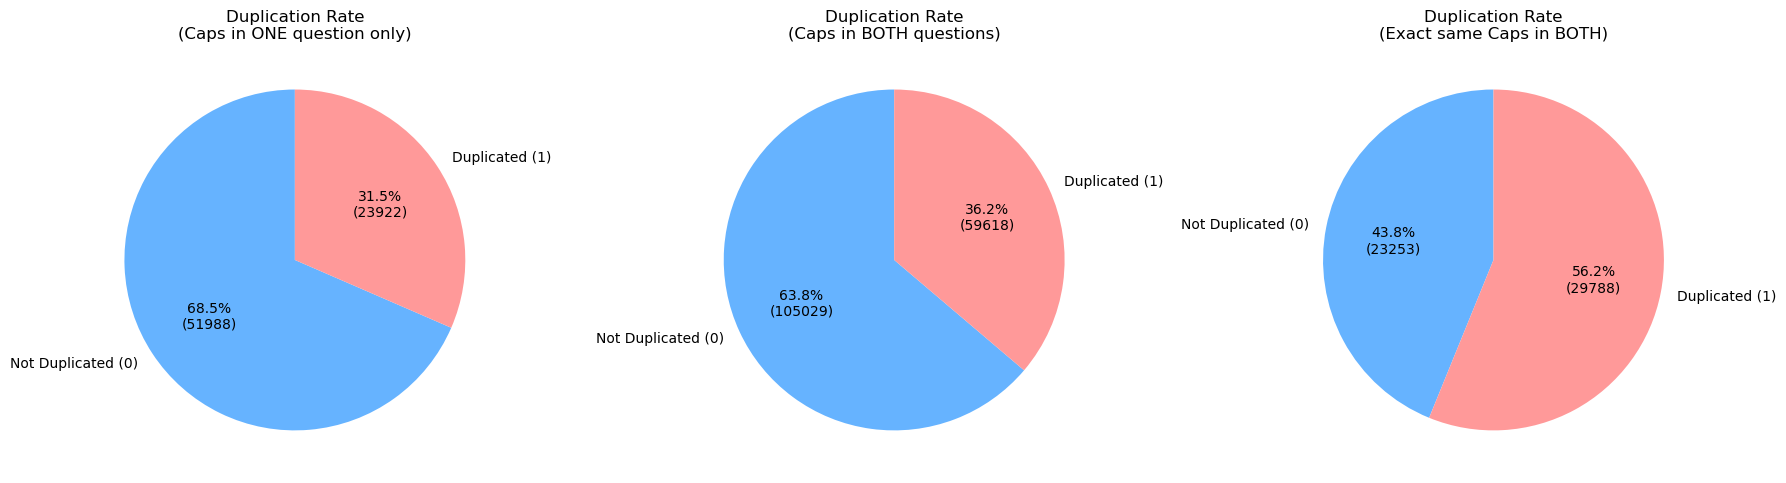

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re

# Create a copy to avoid modifying the original dataframe
copy_df = quora_df.copy()

# 1. Pre-compile regex to cleanly extract words
word_pattern = re.compile(r'\b\w+\b')

def get_capitalized_entities(text):
    words = word_pattern.findall(str(text))
    if len(words) < 2:
        return set()
    return {w for w in words[1:] if w[0].isupper()}

# 2. Extract sets using fast list comprehensions
caps_q1 = [get_capitalized_entities(text) for text in copy_df['question1']]
caps_q2 = [get_capitalized_entities(text) for text in copy_df['question2']]

# 3. Calculate lengths
len_q1 = np.array([len(s) for s in caps_q1])
len_q2 = np.array([len(s) for s in caps_q2])

caps_q1_series = pd.Series(caps_q1)
caps_q2_series = pd.Series(caps_q2)

# 4. Create boolean masks
mask_only_one = ((len_q1 > 0) & (len_q2 == 0)) | ((len_q1 == 0) & (len_q2 > 0))
mask_both = (len_q1 > 0) & (len_q2 > 0)
mask_both_same = mask_both & (caps_q1_series == caps_q2_series)

# --- Custom function for autopct ---
# This closure captures the raw data values to calculate the absolute count
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        # Calculate absolute value from percentage and total
        val = int(round(pct * total / 100.0))
        # Return formatted string: Percentage (Count)
        return '{p:.1f}%\n({v:d})'.format(p=pct, v=val)
    return my_autopct

# 5. Plotting: 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['#66b3ff', '#ff9999']

target_col = 'is_duplicate'
labels_dup = ["Not Duplicated (0)", "Duplicated (1)"]

# --- PIE 1: Entities in ONE question only ---
dist_only_one = copy_df[mask_only_one][target_col].value_counts().sort_index()
axes[0].pie(dist_only_one, labels=labels_dup, 
            autopct=make_autopct(dist_only_one), # Apply custom function
            colors=colors, startangle=90)
axes[0].set_title('Duplication Rate\n(Caps in ONE question only)')

# --- PIE 2: Entities in BOTH questions ---
dist_both = copy_df[mask_both][target_col].value_counts().sort_index()
axes[1].pie(dist_both, labels=labels_dup, 
            autopct=make_autopct(dist_both), # Apply custom function
            colors=colors, startangle=90)
axes[1].set_title('Duplication Rate\n(Caps in BOTH questions)')

# --- PIE 3: Exact same entities in BOTH questions ---
dist_both_same = copy_df[mask_both_same][target_col].value_counts().sort_index()
axes[2].pie(dist_both_same, labels=labels_dup, 
            autopct=make_autopct(dist_both_same), # Apply custom function
            colors=colors, startangle=90)
axes[2].set_title('Duplication Rate\n(Exact same Caps in BOTH)')

# Adjust layout
plt.tight_layout()
plt.show()

## Data Splitting

In [8]:
A_df, test_df = train_test_split(
    quora_df, 
    test_size=0.05, 
    random_state=123
)

train_df, val_df = train_test_split(
    A_df, 
    test_size=0.05, 
    random_state=123
)    

print(f'train_df.shape = {train_df.shape}')
print(f'val_df.shape = {val_df.shape}')
print(f'test_df.shape = {test_df.shape}')

train_df.shape = (291897, 6)
val_df.shape = (15363, 6)
test_df.shape = (16172, 6)


## Models

In [9]:
MODELS_DIR = "models"
ALREADY_TRAINED = os.path.exists(MODELS_DIR)

if not ALREADY_TRAINED:
    os.makedirs(MODELS_DIR)
    print(f"Created '{MODELS_DIR}/' — models will be trained and saved.")
else:
    print(f"'{MODELS_DIR}/' already exists — training will be skipped for any model already on disk.")

'models/' already exists — training will be skipped for any model already on disk.


### Baseline model

In [10]:
CV_PATH       = os.path.join(MODELS_DIR, "count_vectorizer.pkl")
TFIDF_PATH    = os.path.join(MODELS_DIR, "tfidf_vectorizer.pkl")
BASELINE_PATH = os.path.join(MODELS_DIR, "baseline_logistic.pkl")

if (not os.path.exists(CV_PATH) or not os.path.exists(TFIDF_PATH)) and not os.path.exists(BASELINE_PATH):
    # Transform questions to strings (if not we may find some errors)
    q1_train =  utils.cast_list_as_strings(list(train_df["question1"]))
    q2_train =  utils.cast_list_as_strings(list(train_df["question2"]))

    # --- Fitting a Count Vectorizer ---
    if not os.path.exists(CV_PATH):
        count_vectorizer = sklearn.feature_extraction.text.CountVectorizer(ngram_range=(1,1))
        count_vectorizer.fit(q1_train + q2_train)

        utils.save_object(count_vectorizer, CV_PATH)
        print("Count Vectorizer trained and saved")
    else:
        count_vectorizer = utils.load_object(CV_PATH)
        print(f"Loading the Count Vectorizer from {CV_PATH}")
    

    # --- Fitting a TF-IDF ---
    if not os.path.exists(TFIDF_PATH):
        tfidf_vectorizer = sklearn.feature_extraction.text.TfidfVectorizer(
            ngram_range=(1, 1), min_df=3, sublinear_tf=True
        )
        tfidf_vectorizer.fit(q1_train + q2_train)

        utils.save_object(tfidf_vectorizer, TFIDF_PATH)
        print("TF-IDF trained and saved")
    else:
        tfidf_vectorizer = utils.load_object(TFIDF_PATH)
        print(f"Loading the TF-IDF from {TFIDF_PATH}")

    X_tr_q1q2 = utils.get_combined_features(train_df, count_vectorizer=count_vectorizer, tfidf_vectorizer=tfidf_vectorizer)

    # --- Fitting a Logistic Regressor ---
    logistic = sklearn.linear_model.LogisticRegression(solver="liblinear", random_state=123)
    y_train = train_df["is_duplicate"].values
    logistic.fit(X_tr_q1q2, y_train)

    utils.save_object(logistic, BASELINE_PATH)
    print("Logistic Regressor trained and saved")
else:
    print("count_vectorizer.pkl, tfidf_vectorizer.pkl and baseline_logistic.pkl already exists — skipping.")

count_vectorizer.pkl, tfidf_vectorizer.pkl and baseline_logistic.pkl already exists — skipping.


In [11]:
# This cell is for rerunning to assign variables or load objects

if "count_vectorizer" not in vars():   
    count_vectorizer = utils.load_object(CV_PATH)     
    print(f"Loaded count_vectorizer from {CV_PATH}")  

if "tfidf_vectorizer" not in vars():   
    tfidf_vectorizer = utils.load_object(TFIDF_PATH)  
    print(f"Loaded tfidf_vectorizer from {TFIDF_PATH}")

if "logistic" not in vars():           
    logistic = utils.load_object(BASELINE_PATH)       
    print(f"Loaded logistic from {BASELINE_PATH}")   

Loaded count_vectorizer from models/count_vectorizer.pkl
Loaded tfidf_vectorizer from models/tfidf_vectorizer.pkl
Loaded logistic from models/baseline_logistic.pkl


### SBERT Improved Model

The SBERT model uses pre-trained **Sentence-BERT** (`paraphrase-MiniLM-L6-v2`) embeddings
to capture *semantic* similarity between question pairs — the key limitation of the
lexical baseline and improved model.

**Feature design** (mirrors `get_interaction_features_from_df`):

| Half | Feature | Captures |
|------|---------|----------|
| `[0 : 384)` | `\|emb_q1 − emb_q2\|` | *What is different* between the two questions |
| `[384 : 768)` | `emb_q1 ⊙ emb_q2` | *What is shared* between the two questions |

Encoded features for **all three splits** (train / val / test) are saved to `models/`
as `.npy` files so that `reproduce_results.ipynb` can load them in milliseconds
without re-running the encoder.

**Why not RoBERTa, DistilBERT or BART?** See the docstring of
`utils.get_sbert_interaction_features` in `utils.py` for the full justification.

In [12]:
from sentence_transformers import SentenceTransformer  

# --- Paths for the SBERT artefacts -------------------------------------------
# The logistic regression classifier trained on SBERT features
SBERT_CLF_PATH    = os.path.join(MODELS_DIR, "sbert_logistic.pkl")    

# Pre-computed SBERT feature matrices saved as numpy arrays.
# Saving them allows reproduce_results.ipynb to evaluate the model
# without re-encoding all questions (encoding takes ~1-2 min on CPU).
SBERT_FEAT_TRAIN  = os.path.join(MODELS_DIR, "sbert_X_train.npy")     
SBERT_FEAT_VAL    = os.path.join(MODELS_DIR, "sbert_X_val.npy")       
SBERT_FEAT_TEST   = os.path.join(MODELS_DIR, "sbert_X_test.npy")      

# Name of the SBERT checkpoint from the sentence-transformers hub.
# paraphrase-MiniLM-L6-v2 was fine-tuned specifically on paraphrase
# detection datasets — exactly the Quora task — and runs fast on CPU.
SBERT_MODEL_NAME  = "paraphrase-MiniLM-L6-v2"                         

/home/arnau/miniconda3/envs/quora_challenge_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
# Guard: skip entirely if the SBERT classifier is already on disk
# (mirrors the pattern used for the baseline model above).
if not os.path.exists(SBERT_CLF_PATH):  

    # ------------------------------------------------------------------
    # 1. Load the pre-trained SBERT model
    #    The weights are downloaded from HuggingFace Hub on first run
    #    and cached locally, so subsequent runs are instant.
    # ------------------------------------------------------------------
    print(f"Loading SBERT model: {SBERT_MODEL_NAME}")  
    sbert_model = SentenceTransformer(SBERT_MODEL_NAME)  

    # ------------------------------------------------------------------
    # 2. Encode question pairs for each split and save as .npy
    #    We also need the test split features here so that
    #    reproduce_results.ipynb can evaluate without re-encoding.
    # ------------------------------------------------------------------
    for split_name, split_df, feat_path in [  
        ("train", train_df, SBERT_FEAT_TRAIN),  
        ("val",   val_df,   SBERT_FEAT_VAL),    
        ("test",  test_df,  SBERT_FEAT_TEST),   
    ]:  
        if not os.path.exists(feat_path):  
            print(f"\nEncoding SBERT features for {split_name} split...")  
            # get_sbert_interaction_features encodes q1 and q2 separately
            # then returns [|emb_q1 - emb_q2|, emb_q1 * emb_q2]
            X_sbert = utils.get_sbert_interaction_features(split_df, sbert_model)  
            np.save(feat_path, X_sbert)  
            print(f"  Saved to {feat_path}  shape={X_sbert.shape}")  
        else:  
            print(f"  {feat_path} already exists — skipping encoding.")  

    # ------------------------------------------------------------------
    # 3. Load the saved train features and fit a LogisticRegression
    #    We re-load from disk so this cell is self-contained even if
    #    X_sbert was just serialised inside the loop above.
    # ------------------------------------------------------------------
    X_train_sbert = np.load(SBERT_FEAT_TRAIN)  
    y_train_sbert = train_df["is_duplicate"].values  

    print("\nTraining LogisticRegression on SBERT features...")  
    # Same solver and random_state as the other models for fair comparison.
    # max_iter=1000 gives liblinear enough budget to converge on 768 dense
    # features (default 100 is sometimes insufficient for dense inputs).
    sbert_logistic = sklearn.linear_model.LogisticRegression(  
        solver="liblinear", random_state=123, max_iter=1000    
    )                                                           
    sbert_logistic.fit(X_train_sbert, y_train_sbert)           

    utils.save_object(sbert_logistic, SBERT_CLF_PATH)          
    print(f"SBERT Logistic Regressor saved to {SBERT_CLF_PATH}")  

else:  
    print(f"{SBERT_CLF_PATH} already exists — skipping SBERT training.")  

models/sbert_logistic.pkl already exists — skipping SBERT training.


### SBERT + Graph ("Magic") Features Model

This model combines the semantic SBERT embeddings with **graph-based features**
— the single biggest gain found by virtually every top-10 solution in this competition.

**Why graph features work:**  
The Quora dataset is a graph: each unique question is a node and each CSV row
is an undirected edge q1─q2.  Quora built the dataset by upsampling duplicate pairs,
which embedded two structural signals:

1. **Question frequency** (`q_freq`): frequently-appearing questions are hub nodes —
   questions asked many times — and repeated questions are almost always paraphrases.
2. **Common neighbors** (`intersect`): if q1 and q2 share even one graph neighbor,
   the probability of them being a duplicate drops from ~80% to <40%
   (InData Labs analysis; jturkewitz +0.03 Kaggle notebook).

**Feature layout** (774 dimensions total):

| Block | Columns | Source |
|-------|---------|--------|
| SBERT diff `\|emb_q1 − emb_q2\|` | 0–383 | `get_sbert_interaction_features` |
| SBERT prod `emb_q1 ⊙ emb_q2` | 384–767 | `get_sbert_interaction_features` |
| q1_freq, q2_freq, freq_min, freq_max, freq_diff, intersect | 768–773 | `get_graph_features` |

**No leakage**: `freq_dict` and `neighbor_dict` are built from `train_df` only
and applied read-only to val and test.

In [14]:
from sentence_transformers import SentenceTransformer

SBERT_GRAPH_CLF_PATH   = os.path.join(MODELS_DIR, "sbert_graph_logistic.pkl")  
SBERT_GRAPH_FEAT_TRAIN = os.path.join(MODELS_DIR, "sbert_graph_X_train.npy")   
SBERT_GRAPH_FEAT_VAL   = os.path.join(MODELS_DIR, "sbert_graph_X_val.npy")     
SBERT_GRAPH_FEAT_TEST  = os.path.join(MODELS_DIR, "sbert_graph_X_test.npy")    

# Persist the graph dictionaries so reproduce_results.ipynb can reuse them
# without rebuilding from scratch (building neighbor_dict takes ~30 s on CPU).
FREQ_DICT_PATH     = os.path.join(MODELS_DIR, "freq_dict.pkl")      
NEIGHBOR_DICT_PATH = os.path.join(MODELS_DIR, "neighbor_dict.pkl")  

In [15]:
# Guard: skip entirely if the SBERT+Graph classifier is already on disk.
if not os.path.exists(SBERT_GRAPH_CLF_PATH):  

    # ------------------------------------------------------------------
    # 1. Build graph dictionaries from TRAINING data only (no leakage).
    #    freq_dict[q]     = how often question q appears in train_df
    #    neighbor_dict[q] = set of questions paired with q in train_df
    # ------------------------------------------------------------------
    print("Building freq_dict and neighbor_dict from train_df...")  
    freq_dict     = utils.build_freq_dict(train_df)      
    neighbor_dict = utils.build_neighbor_dict(train_df)  
    utils.save_object(freq_dict,     FREQ_DICT_PATH)     
    utils.save_object(neighbor_dict, NEIGHBOR_DICT_PATH) 
    print(f"  Unique questions in graph: {len(neighbor_dict)}")  

    # ------------------------------------------------------------------
    # 2. Extract combined SBERT + graph features for each split.
    #    get_sbert_graph_features loads the pre-computed SBERT .npy files
    #    (saved by the SBERT section above) to avoid re-encoding.
    # ------------------------------------------------------------------
    # Load the SBERT model only if a .npy file is missing (fallback)
    _sbert_model = None 

    for split_name, split_df, sbert_path, out_path in [  
        ("train", train_df, SBERT_FEAT_TRAIN, SBERT_GRAPH_FEAT_TRAIN),  
        ("val",   val_df,   SBERT_FEAT_VAL,   SBERT_GRAPH_FEAT_VAL),    
        ("test",  test_df,  SBERT_FEAT_TEST,  SBERT_GRAPH_FEAT_TEST),   
    ]:  
        if not os.path.exists(out_path):  
            if not os.path.exists(sbert_path) and _sbert_model is None:  
                print(f"  SBERT .npy not found — loading model {SBERT_MODEL_NAME}")  
                _sbert_model = SentenceTransformer(SBERT_MODEL_NAME, device=SBERT_DEVICE)  
            print(f"\nExtracting SBERT+Graph features for {split_name} split...")  
            X_sg = utils.get_sbert_graph_features(  
                split_df, _sbert_model,             
                freq_dict, neighbor_dict,           
                sbert_feat_path=sbert_path,         
            )                                       
            np.save(out_path, X_sg)                 
            print(f"  Saved {out_path}  shape={X_sg.shape}")  
        else:  
            print(f"  {out_path} already exists — skipping.")  

    # ------------------------------------------------------------------
    # 3. Train LogisticRegression on the combined (774-dim) features.
    #    Same solver and random_state as all other models for fair comparison.
    # ------------------------------------------------------------------
    X_train_sg    = np.load(SBERT_GRAPH_FEAT_TRAIN)          
    y_train_sg    = train_df["is_duplicate"].values           

    print("\nTraining LogisticRegression on SBERT+Graph features...")  
    sbert_graph_logistic = sklearn.linear_model.LogisticRegression(  
        solver="liblinear", random_state=123, max_iter=1000          
    )                                                                  
    sbert_graph_logistic.fit(X_train_sg, y_train_sg)                  

    utils.save_object(sbert_graph_logistic, SBERT_GRAPH_CLF_PATH)     
    print(f"SBERT+Graph Logistic Regressor saved to {SBERT_GRAPH_CLF_PATH}")  

else:  
    print(f"{SBERT_GRAPH_CLF_PATH} already exists — skipping SBERT+Graph training.")  
    freq_dict     = utils.load_object(FREQ_DICT_PATH)      
    neighbor_dict = utils.load_object(NEIGHBOR_DICT_PATH)  

models/sbert_graph_logistic.pkl already exists — skipping SBERT+Graph training.


In [16]:
# Quick sanity-check: evaluate the SBERT+Graph model on train and val.
# Full train / val / test evaluation lives in reproduce_results.ipynb.

sbert_graph_logistic = utils.load_object(SBERT_GRAPH_CLF_PATH)  
X_train_sg = np.load(SBERT_GRAPH_FEAT_TRAIN)                    
X_val_sg   = np.load(SBERT_GRAPH_FEAT_VAL)                      

y_train_eval = train_df["is_duplicate"].values  
y_val_eval   = val_df[  "is_duplicate"].values  

sg_rows = [  
    utils.evaluate_model(sbert_graph_logistic, X_train_sg, y_train_eval, "sbert_graph", "train"),  
    utils.evaluate_model(sbert_graph_logistic, X_val_sg,   y_val_eval,   "sbert_graph", "val"),   
]  

display(pd.DataFrame(sg_rows))

,model,split,roc_auc,precision,recall,f1,accuracy
0,sbert_graph,train,0.9451,0.8457,0.7866,0.8151,0.8684
1,sbert_graph,val,0.9448,0.8522,0.7752,0.8119,0.8675
